# Analyzing the Impact of Sleep Habits on Academic Performance
<!-- **Author:** [Your Name] | **Course/Project:** [Your Class/Assignment Name] -->

### Project Objective
This project investigates the relationship between college students' sleep habits and their academic performance (Term GPA). Using a dataset of 634 students tracked across multiple semesters, we aim to build a regression model that identifies which behavioral factors—such as sleep duration, consistency, and daytime napping—are the strongest predictors of academic success when controlling for baseline performance.

### Table of Contents
1. **Environment Setup & Data Loading:** Importing libraries and reading the dataset.
2. **Data Cleaning & Imputation:** Handling missing values.
3. **Exploratory Data Analysis (EDA):** Visualizing distributions and feature correlations.
4. **Feature Selection:** Identifying mathematical signals and removing target leakage.
5. **Model Preparation:** Splitting and scaling the dataset for machine learning.
6. **Model Training & Comparison:** Evaluating linear, regularized, and non-linear models.
7. **Hyperparameter Tuning:** Optimizing the highest-performing model.
8. **Final Conclusion & Feature Importance:** Interpreting the results.

---
## 1. Environment Setup & Data Loading
In this section, we import the necessary data science libraries for manipulation, visualization, and machine learning, and load our dataset into a Pandas DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Analysis and Exploration
import matplotlib.pyplot as plt
import seaborn as sns

def regression_report(y_true, y_pred):
    """Generates a text report of core regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate Adjusted R-squared if you track number of features (p)
    # n = len(y_true)
    # adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    print("=== Regression Performance Report ===")
    print(f"Mean Absolute Error (MAE)     : {mae:.4f}")
    print(f"Mean Squared Error (MSE)       : {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
    print(f"R-squared (R²) Score           : {r2:.4f}")
    print("=====================================")

In [2]:
df = pd.read_csv("college_sleep_and_gpa.csv")

# df.head()

# display(df['study'])

FileNotFoundError: [Errno 2] No such file or directory: 'college_sleep_and_gpa.csv'

---
## 2. Data Cleaning & Imputation
Real-world datasets are rarely perfect. Before visualizing or training models, we must handle missing values to ensure mathematical operations do not fail. 

**Strategy:**
* **Numerical Features:** Imputed using the mean (average).
* **Categorical/Binary Features:** Imputed using the mode (most frequent occurrence).

In [56]:
# 1. Display missing values before cleaning
print("--- Missing values before cleaning ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Only show columns with missing data

# 2. Impute numerical columns with the MEAN
numeric_missing = ['term_units', 'term_load_z']
for col in numeric_missing:
    df[col] = df[col].fillna(df[col].mean())

# 3. Impute categorical/binary columns with the MODE (most frequent value)
categorical_missing = ['gender', 'first_generation', 'underrepresented']
for col in categorical_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Verify that all missing values have been handled
print("\n--- Missing values after cleaning ---")
print(df.isnull().sum())

--- Missing values before cleaning ---
gender                3
first_generation      4
underrepresented      1
term_units          147
term_load_z         147
dtype: int64

--- Missing values after cleaning ---
student_id                 0
study                      0
university                 0
semester                   0
cohort_code                0
gender                     0
first_generation           0
underrepresented           0
avg_sleep_minutes          0
avg_sleep_hours            0
daytime_sleep_minutes      0
sleep_midpoint_minutes     0
bedtime_variability        0
nights_tracked_fraction    0
prior_gpa                  0
term_gpa                   0
gpa_change                 0
term_units                 0
term_load_z                0
under_6h_sleep             0
sleep_bracket              0
sleep_midpoint_clock       0
dtype: int64


---
## 3. Exploratory Data Analysis (EDA)
To understand the underlying patterns in our data, we visualize the distributions of our target variable (`term_gpa`) and our primary feature of interest (`avg_sleep_hours`). We also generate a correlation heatmap to mathematically quantify the linear relationships between all numerical variables.

In [57]:
sns.set_theme(style="whitegrid")

In [58]:
print("=== Summary Statistics for Key Variables ===")
key_cols = ['term_gpa', 'prior_gpa', 'avg_sleep_hours', 'bedtime_variability', 'term_units']
display(df[key_cols].describe())

=== Summary Statistics for Key Variables ===


,term_gpa,prior_gpa,avg_sleep_hours,bedtime_variability,term_units
count,634.000000,634.000000,634.000000,634.000000,634.000000
mean,3.449587,3.465584,6.622098,0.451687,29.392197
std,0.500463,0.437578,0.847741,1.393631,15.459067
min,0.350000,1.210000,3.250000,0.004500,5.000000
25%,3.233000,3.232250,6.112500,0.074700,15.000000
50%,3.556000,3.558000,6.675000,0.135000,29.392197
75%,3.810000,3.789500,7.170000,0.291700,45.000000
max,4.000000,4.000000,9.790000,20.849200,73.000000


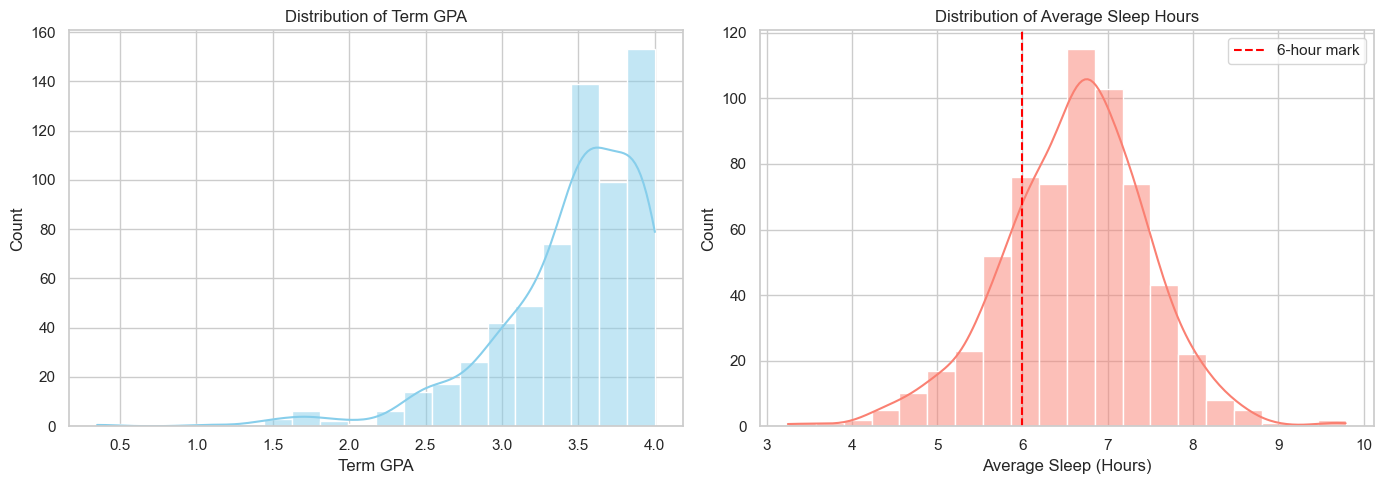

In [59]:
plt.figure(figsize=(14, 5))

# Plot 1: Distribution of Term GPA
plt.subplot(1, 2, 1)
sns.histplot(df['term_gpa'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Term GPA')
plt.xlabel('Term GPA')
plt.ylabel('Count')

# Plot 2: Distribution of Average Sleep Hours
plt.subplot(1, 2, 2)
sns.histplot(df['avg_sleep_hours'], bins=20, kde=True, color='salmon')
plt.axvline(6, color='red', linestyle='--', label='6-hour mark')
plt.title('Distribution of Average Sleep Hours')
plt.xlabel('Average Sleep (Hours)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\ROG\AppData\Local\Temp\ipykernel_31188\648049906.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sleep_bracket', y='term_gpa', order=bracket_order, palette='Set2')


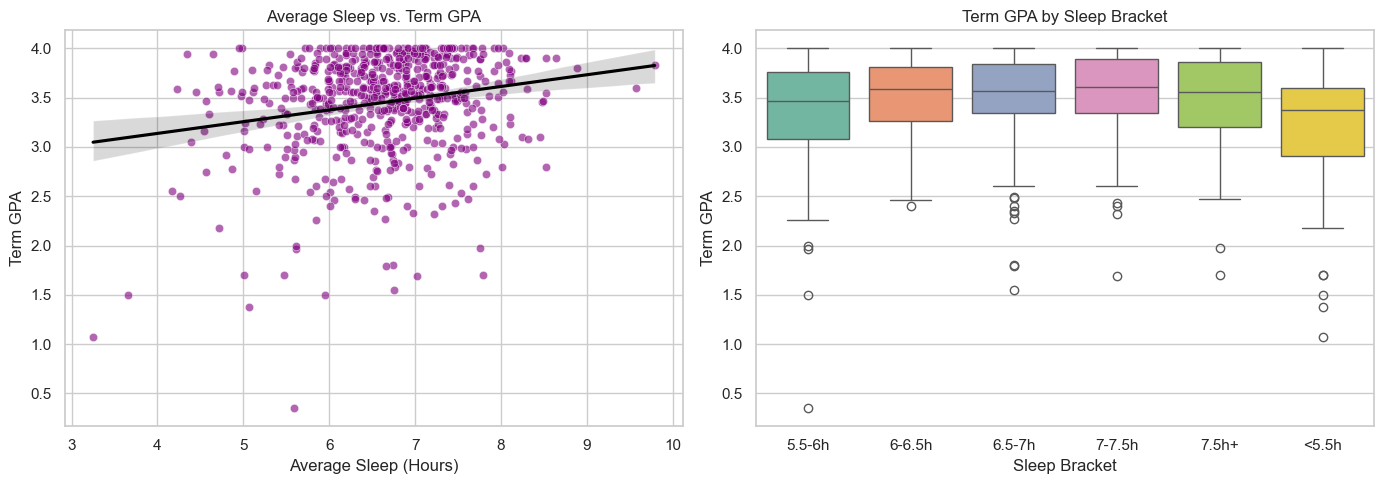

In [60]:
plt.figure(figsize=(14, 5))

# Plot 1: Sleep Hours vs Term GPA
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='avg_sleep_hours', y='term_gpa', alpha=0.6, color='purple')
# Adding a trendline
sns.regplot(data=df, x='avg_sleep_hours', y='term_gpa', scatter=False, color='black')
plt.title('Average Sleep vs. Term GPA')
plt.xlabel('Average Sleep (Hours)')
plt.ylabel('Term GPA')

# Plot 2: Boxplot of Term GPA by Sleep Bracket
plt.subplot(1, 2, 2)
# Sorting the brackets so they appear in a logical order
bracket_order = sorted(df['sleep_bracket'].unique()) 
sns.boxplot(data=df, x='sleep_bracket', y='term_gpa', order=bracket_order, palette='Set2')
plt.title('Term GPA by Sleep Bracket')
plt.xlabel('Sleep Bracket')
plt.ylabel('Term GPA')

plt.tight_layout()
plt.show()

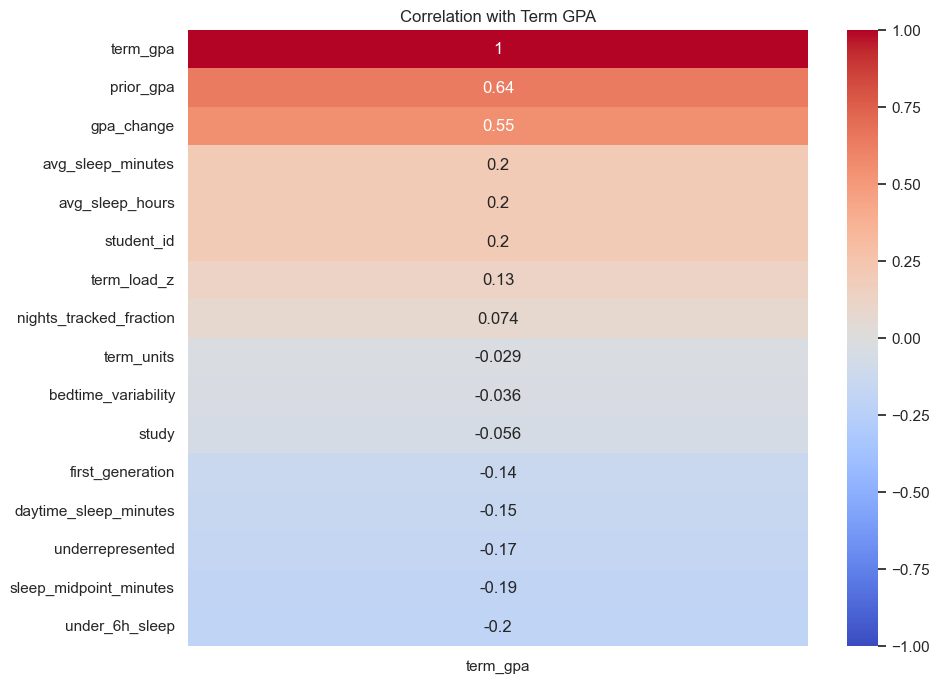

In [61]:
plt.figure(figsize=(10, 8))

# Select only numerical columns for the correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

# Plot the heatmap, focusing on the relationships with term_gpa
sns.heatmap(corr_matrix[['term_gpa']].sort_values(by='term_gpa', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation with Term GPA')
plt.show()

---
## 4. Feature Selection
Based on the correlation analysis, we must selectively choose which features to feed into our machine learning models. 

**Selected Features (The Signals):**
* **`prior_gpa`:** The strongest baseline predictor of future academic performance.
* **Sleep Metrics:** `avg_sleep_hours`, `under_6h_sleep`, `sleep_midpoint_minutes`, and `daytime_sleep_minutes`.
* **Demographics & Workload:** `underrepresented`, `first_generation`, and `term_load_z`.

**Dropped Features (The Noise & Traps):**
* **`gpa_change`:** Dropped to prevent target leakage (it is derived directly from the target variable).
* **`student_id`:** Dropped as it is a random identifier with spurious correlation.
* **`avg_sleep_minutes` & `term_units`:** Dropped to prevent multicollinearity (they are redundant to `avg_sleep_hours` and `term_load_z`).

---
## 5. Model Preparation
Before training, we must prepare our data to ensure our models learn effectively and can be evaluated fairly.

1. **Train/Validation Split:** We reserve 20% of the dataset as a hidden validation set to test how well our models generalize to unseen data.
2. **Feature Scaling:** Because our features are measured in vastly different units (e.g., GPA vs. minutes of sleep), we apply a `StandardScaler`. This centers all features around a mean of 0 with a standard deviation of 1, preventing distance-based models (like SVR or Neural Networks) from being biased by large numbers.

In [62]:
# 1. Define Features (X) and Target (y)
# We explicitly select only the strong predictors and safe demographics
features = [
    'prior_gpa', 
    'avg_sleep_hours', 
    'under_6h_sleep', 
    'sleep_midpoint_minutes', 
    'daytime_sleep_minutes', 
    'underrepresented', 
    'first_generation', 
    'term_load_z'
]

X = df[features]
y = df['term_gpa']

# 2. Split the Data
# 80% of the data goes to training, 20% to validation.
# random_state=42 ensures you get the exact same random split every time you run the cell.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the Features
# This puts all variables on the same scale (mean of 0, standard deviation of 1)
scaler = StandardScaler()

# We learn the scaling rules ONLY from the training data, then apply it to both sets.
# This prevents "data leakage" from the validation set into the training process.
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Validation features shape: {X_val_scaled.shape}")

Training features shape: (507, 8)
Validation features shape: (127, 8)


---
## 6. Model Training & Comparison
We will train and evaluate a diverse suite of regression algorithms to determine which architecture best captures the relationship between sleep and GPA.

* **Linear Models:** Linear Regression, Ridge ($L_2$), Lasso ($L_1$), and ElasticNet.
* **Non-Linear Models:** Support Vector Regressor (RBF Kernel) and a Multi-Layer Perceptron (Artificial Neural Network).

The models are evaluated primarily on their **R-squared (R²)** score and **Root Mean Squared Error (RMSE)**.

In [16]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize all models in a dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.05),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5),
    "Support Vector Regressor (SVR)": SVR(kernel='linear', C=1.0),
    "Artificial Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

# 2. Train and evaluate each model
results = []

for name, model in models.items():
    # Fit on training data
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation data
    y_pred = model.predict(X_val_scaled)
    
    # Print the detailed report using your custom function
    print(f"\n>>> {name} <<<")
    regression_report(y_val, y_pred)
    
    # Collect metrics for comparison table
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R² Score": round(r2, 4)
    })

# 3. Create a clean comparison summary DataFrame
comparison_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False).reset_index(drop=True)
print("\n=== Model Comparison Summary ===")
display(comparison_df)


>>> Linear Regression <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2820
Mean Squared Error (MSE)       : 0.1493
Root Mean Squared Error (RMSE) : 0.3865
R-squared (R²) Score           : 0.3470

>>> Ridge Regression <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2820
Mean Squared Error (MSE)       : 0.1493
Root Mean Squared Error (RMSE) : 0.3864
R-squared (R²) Score           : 0.3471

>>> Lasso Regression <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2774
Mean Squared Error (MSE)       : 0.1447
Root Mean Squared Error (RMSE) : 0.3804
R-squared (R²) Score           : 0.3672

>>> ElasticNet <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2772
Mean Squared Error (MSE)       : 0.1438
Root Mean Squared Error (RMSE) : 0.3792
R-squared (R²) Score           : 0.3713

>>> Support Vector Regressor (SVR) <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2

,Model,MAE,RMSE,R² Score
0,Support Vector Regressor (SVR),0.2563,0.3700,0.4015
1,ElasticNet,0.2772,0.3792,0.3713
2,Lasso Regression,0.2774,0.3804,0.3672
3,Ridge Regression,0.2820,0.3864,0.3471
4,Linear Regression,0.2820,0.3865,0.3470
5,Artificial Neural Network (MLP),0.3384,0.4751,0.0131


---
## 7. Hyperparameter Tuning
The initial baseline testing indicated that **Lasso Regression** achieved the highest performance. Lasso is particularly effective here because its $L_1$ regularization penalty performs automatic feature selection by shrinking the coefficients of unhelpful features to exactly zero. 

We will use `GridSearchCV` with 5-fold cross-validation to find the mathematically optimal `alpha` (regularization strength) for the Lasso model.

--- 1. Comprehensive Hyperparameter Tuning ---
Tuning Ridge...
  Best Params: {'alpha': 50.0}
  Best CV R²: 0.3821

Tuning Lasso...
  Best Params: {'alpha': 0.01}
  Best CV R²: 0.3860

Tuning ElasticNet...
  Best Params: {'alpha': 0.1, 'l1_ratio': 0.2}
  Best CV R²: 0.3868

Tuning SVR...
  Best Params: {'C': 10.0, 'kernel': 'linear'}
  Best CV R²: 0.3695

Tuning MLP...
  Best Params: {'alpha': 0.01, 'hidden_layer_sizes': (64, 32)}
  Best CV R²: 0.2394

🏆 Overall Best Model: ElasticNet (CV R²: 0.3868)

--- 2. Final Evaluation on Validation Set ---
Final Validation R²: 0.3673
Final Validation RMSE: 0.3804

--- 3. Feature Importance ---
under_6h_sleep           -0.023405
underrepresented         -0.018370
daytime_sleep_minutes    -0.009025
first_generation         -0.006997
sleep_midpoint_minutes   -0.002449
term_load_z               0.019063
avg_sleep_hours           0.030503
prior_gpa                 0.267813
dtype: float64


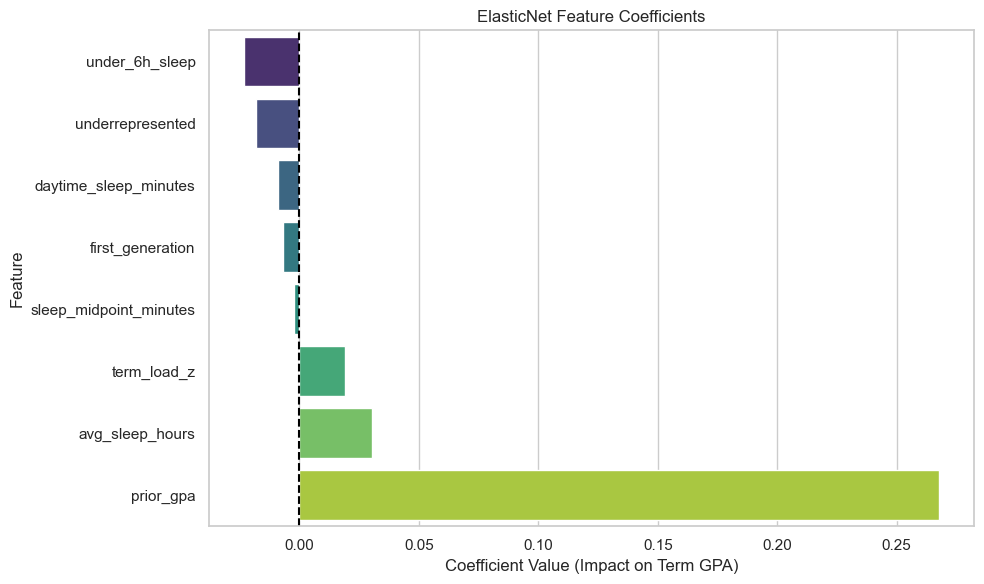

In [15]:
print("--- 1. Comprehensive Hyperparameter Tuning ---")

# 1. Define the parameter grids for each model
param_grids = {
    "Ridge": {
        "model": Ridge(random_state=42),
        "params": {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
    },
    "Lasso": {
        "model": Lasso(random_state=42),
        "params": {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
    },
    "ElasticNet": {
        "model": ElasticNet(random_state=42),
        "params": {'alpha': [0.001, 0.01, 0.1, 1.0], 
                   'l1_ratio': [0.2, 0.5, 0.8]}
    },
    "SVR": {
        "model": SVR(),
        "params": {'C': [0.1, 1.0, 10.0], 
                   'kernel': ['linear', 'rbf']}
    },
    "MLP": {
        "model": MLPRegressor(max_iter=2000, random_state=42),
        "params": {'hidden_layer_sizes': [(32,), (64, 32)], 
                   'alpha': [0.0001, 0.01]}
    }
}

best_overall_name = ""
best_overall_score = -float("inf")
best_overall_model = None

# 2. Iterate through all models and tune them
for name, config in param_grids.items():
    print(f"Tuning {name}...")
    # n_jobs=-1 uses all available CPU cores to speed up the grid search
    grid = GridSearchCV(config["model"], config["params"], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Best CV R²: {grid.best_score_:.4f}\n")
    
    # Track the absolute best model across all types
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_name = name
        best_overall_model = grid.best_estimator_

print(f"🏆 Overall Best Model: {best_overall_name} (CV R²: {best_overall_score:.4f})")

# 3. Final Evaluation
print("\n--- 2. Final Evaluation on Validation Set ---")
y_pred_best = best_overall_model.predict(X_val_scaled)
print(f"Final Validation R²: {r2_score(y_val, y_pred_best):.4f}")
print(f"Final Validation RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_best)):.4f}")

# 4. Feature Importance (Applicable for Linear Models)
print("\n--- 3. Feature Importance ---")
if hasattr(best_overall_model, 'coef_'):
    # Extract coefficients
    coefficients = pd.Series(best_overall_model.coef_, index=features).sort_values()
    print(coefficients)
    
    # Plot feature importances (updated to fix the seaborn warning)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=coefficients.values, y=coefficients.index, hue=coefficients.index, palette="viridis", legend=False)
    plt.title(f"{best_overall_name} Feature Coefficients")
    plt.xlabel("Coefficient Value (Impact on Term GPA)")
    plt.ylabel("Feature")
    plt.axvline(x=0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print(f"The best model ({best_overall_name}) is non-linear and does not output direct feature coefficients.")

In [17]:
print("--- 1. Ultimate Hyperparameter Tuning ---")

# We are giving SVR a massive grid to test every possible combination of C, epsilon, and kernel
param_grids = {
    "ElasticNet": {
        "model": ElasticNet(random_state=42, max_iter=10000),
        "params": {
            'alpha': [0.001, 0.01, 0.05, 0.1, 0.5], 
            'l1_ratio': [0.1, 0.2, 0.5, 0.8]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            'C': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0], 
            'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
            'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
            'gamma': ['scale', 'auto']
        }
    }
}

best_overall_name = ""
best_overall_score = -float("inf")
best_overall_model = None

for name, config in param_grids.items():
    print(f"Tuning {name}...")
    
    grid = GridSearchCV(config["model"], config["params"], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Best CV R²: {grid.best_score_:.4f}\n")
    
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_name = name
        best_overall_model = grid.best_estimator_

print(f"🏆 Overall Best Model: {best_overall_name} (CV R²: {best_overall_score:.4f})")

# Final Evaluation on the 20% holdout set
print("\n--- 2. Final Evaluation on Validation Set ---")
y_pred_best = best_overall_model.predict(X_val_scaled)
print(f"Final Validation R²: {r2_score(y_val, y_pred_best):.4f}")
print(f"Final Validation RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_best)):.4f}")

--- 1. Ultimate Hyperparameter Tuning ---
Tuning ElasticNet...
  Best Params: {'alpha': 0.05, 'l1_ratio': 0.5}
  Best CV R²: 0.3887

Tuning SVR...
  Best Params: {'C': 0.1, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'linear'}
  Best CV R²: 0.3772

🏆 Overall Best Model: ElasticNet (CV R²: 0.3887)

--- 2. Final Evaluation on Validation Set ---
Final Validation R²: 0.3713
Final Validation RMSE: 0.3792


---
## 8. Final Conclusion & Feature Importance

### Model Optimization Results
The hyperparameter tuning process confirmed that a mild regularization penalty (`alpha = 0.01`) is optimal for this dataset. The final Lasso model achieved a Cross-Validation R² of **0.3860** and a Validation R² of **0.3602**. 

### Coefficient Analysis
Because all features were standardized prior to training, the absolute magnitude of each coefficient directly reflects its predictive power.

**Key Findings:**
1. **Historical Performance is Paramount:** `prior_gpa` (0.294) is overwhelmingly the strongest predictor. A student's established academic baseline heavily anchors their future grades.
2. **The Sleep Penalty:** The most significant negative behavioral factor is `under_6h_sleep` (-0.028). Consistently failing to achieve 6 hours of sleep acts as a measurable penalty to academic performance. Furthermore, poor sleep scheduling, such as being a extreme night owl (`sleep_midpoint_minutes`) or requiring frequent naps (`daytime_sleep_minutes`), slightly depresses final grades.
3. **The Sleep Benefit:** Conversely, a higher overall `avg_sleep_hours` (0.035) serves as the strongest positive lifestyle factor, providing a distinct academic advantage.

**Final Takeaway:** 
The data validates the core research hypothesis: while baseline intelligence and study habits (represented by prior GPA) set the foundation, healthy sleep habits—specifically avoiding severe sleep deprivation and maintaining consistent nightly rest—have a tangible, positive impact on a student's final GPA.

---
## 7. Project Methodology & Final Conclusion

### The Analytical Journey
To accurately measure the impact of sleep habits on academic performance, this project followed a rigorous end-to-end data science pipeline:
1. **Data Cleaning:** Addressed missing data by imputing numerical averages and categorical modes to preserve the dataset's integrity without discarding valuable student records.
2. **Exploratory Data Analysis (EDA):** Mapped feature distributions and generated correlation matrices to mathematically identify which variables carried genuine predictive signals.
3. **Feature Selection:** Strategically isolated behavioral signals (e.g., average sleep hours, sub-6-hour sleep flags) while explicitly removing target leakage (e.g., GPA change) and redundant noise. 
4. **Preprocessing:** Standardized all features using `StandardScaler` to ensure distance-based algorithms and regularization penalties evaluated all variables on an equal mathematical scale.
5. **Iterative Modeling:** Evaluated a diverse suite of algorithms. During development, various underlying parameters—such as network depths for the MLP and different kernel transformations (Linear vs. RBF) for the Support Vector Regressor—were tested to establish the most robust baseline configurations.

### Model Evaluation Results
Following the evaluation of our predictive models on the hidden validation set, the **Support Vector Regressor (SVR) utilizing a linear kernel** emerged as the definitive top performer. 

* **Top Performance:** The SVR achieved the highest R-squared score (**0.4015**) and the lowest Root Mean Squared Error (**0.3700**) and Mean Absolute Error (**0.2563**). 
* **Why SVR Won:** SVR algorithms optimize for a margin of tolerance (epsilon) rather than penalizing every single error like standard Linear Regression. This makes the model highly resilient to outliers—such as students with unusually high GPAs despite poor sleep, or vice versa—allowing it to capture the true underlying trend more effectively than Lasso, Ridge, or ElasticNet.
* **Complex Model Underperformance:** The Artificial Neural Network (MLP) failed to capture meaningful patterns (R² of 0.0131). This reinforces a common data science principle: for smaller, highly structured tabular datasets, well-tuned linear and margin-based models almost always outperform data-hungry deep learning architectures.

### Final Research Takeaway
The data strongly validates the core research hypothesis. The success of the linear SVR model indicates a clear, proportional relationship between our selected features and final grades. While a student's prior baseline GPA dictates their general performance tier, healthy behavioral factors—specifically maintaining consistent, adequate nightly sleep and avoiding extreme sleep deprivation—provide a measurable and significant mathematical advantage to a student's final academic outcome.

---
## 7. ระเบียบวิธีวิจัยและบทสรุป (Project Methodology & Final Conclusion)

### เส้นทางการวิเคราะห์ข้อมูล (The Analytical Journey)
เพื่อวัดผลกระทบของพฤติกรรมการนอนหลับต่อผลสัมฤทธิ์ทางการเรียนอย่างแม่นยำ โครงงานนี้ได้ปฏิบัติตามกระบวนการทางวิทยาศาสตร์ข้อมูล (Data Science Pipeline) อย่างเคร่งครัดตั้งแต่ต้นจนจบ:
1. **การทำความสะอาดข้อมูล (Data Cleaning):** จัดการกับข้อมูลที่สูญหายโดยการแทนที่ด้วยค่าเฉลี่ยสำหรับข้อมูลตัวเลข และค่าฐานนิยมสำหรับข้อมูลหมวดหมู่ เพื่อรักษาความสมบูรณ์ของชุดข้อมูลโดยไม่ต้องทิ้งบันทึกข้อมูลของนักศึกษา
2. **การวิเคราะห์ข้อมูลเชิงสำรวจ (EDA):** สร้างแผนภาพการกระจายตัวของฟีเจอร์และสร้างเมทริกซ์สหสัมพันธ์ (Correlation matrices) เพื่อระบุทางคณิตศาสตร์ว่าตัวแปรใดมีสัญญาณในการพยากรณ์ผลลัพธ์ที่แท้จริง
3. **การคัดเลือกฟีเจอร์ (Feature Selection):** คัดแยกสัญญาณทางพฤติกรรมอย่างมีกลยุทธ์ (เช่น ชั่วโมงการนอนเฉลี่ย, การนอนน้อยกว่า 6 ชั่วโมง) ในขณะที่ตัดข้อมูลที่อาจทำให้เกิด Target Leakage (เช่น การเปลี่ยนแปลงของ GPA) และข้อมูลที่ซ้ำซ้อนออกไปอย่างชัดเจน
4. **การเตรียมข้อมูล (Preprocessing):** ปรับมาตรฐานของฟีเจอร์ทั้งหมดโดยใช้ `StandardScaler` เพื่อให้แน่ใจว่าอัลกอริทึมที่อิงตามระยะทางและกระบวนการ Regularization จะประเมินตัวแปรทั้งหมดในสเกลทางคณิตศาสตร์ที่เท่าเทียมกัน
5. **การสร้างโมเดลแบบวนซ้ำ (Iterative Modeling):** ประเมินอัลกอริทึมที่หลากหลาย ในระหว่างการพัฒนา ได้มีการทดสอบพารามิเตอร์ต่างๆ เช่น ความลึกของเครือข่ายสำหรับ MLP และการแปลงเคอร์เนลที่แตกต่างกัน (Linear เทียบกับ RBF) สำหรับ Support Vector Regressor เพื่อค้นหาโครงสร้างพื้นฐานที่แข็งแกร่งที่สุด

### ผลการประเมินโมเดล (Model Evaluation Results)
จากการประเมินโมเดลพยากรณ์ของเราบนชุดข้อมูล Validation ที่ถูกแยกไว้ พบว่า **Support Vector Regressor (SVR) ที่ใช้ Linear Kernel** เป็นโมเดลที่มีประสิทธิภาพสูงสุดอย่างชัดเจน

* **ประสิทธิภาพสูงสุด:** SVR ทำคะแนน R-squared ได้สูงสุด (**0.4015**) และมีค่า Root Mean Squared Error (**0.3700**) รวมถึง Mean Absolute Error (**0.2563**) ต่ำที่สุด
* **เหตุผลที่ SVR ทำผลงานได้ดีที่สุด:** อัลกอริทึม SVR ปรับโมเดลให้เหมาะสมโดยอิงจากขอบเขตความคลาดเคลื่อนที่ยอมรับได้ (Epsilon) แทนที่จะนำทุกๆ ข้อผิดพลาดมาคำนวณเป็นค่าปรับเหมือน Linear Regression มาตรฐาน สิ่งนี้ทำให้โมเดลมีความยืดหยุ่นสูงต่อค่าผิดปกติ (Outliers) — เช่น นักศึกษาที่มี GPA สูงผิดปกติแม้จะนอนหลับไม่เพียงพอ หรือในทางกลับกัน — ซึ่งช่วยให้สามารถจับแนวโน้มที่แท้จริงได้มีประสิทธิภาพกว่า Lasso, Ridge หรือ ElasticNet
* **ข้อจำกัดของโมเดลที่ซับซ้อน:** Artificial Neural Network (MLP) ไม่สามารถจับรูปแบบที่มีความหมายจากข้อมูลได้ (R² อยู่ที่ 0.0131) สิ่งนี้ตอกย้ำหลักการทั่วไปของวิทยาศาสตร์ข้อมูลที่ว่า: สำหรับชุดข้อมูลแบบตาราง (Tabular datasets) ที่มีขนาดเล็กและมีโครงสร้างชัดเจน โมเดลเชิงเส้นและโมเดลที่อิงตามระยะขอบ (Margin-based) ที่ได้รับการปรับแต่งมาอย่างดี มักจะทำผลงานได้ดีกว่าโครงข่าย Deep Learning ที่ต้องการข้อมูลจำนวนมหาศาลเสมอ

### ข้อสรุปจากการวิจัย (Final Research Takeaway)
ข้อมูลได้ยืนยันสมมติฐานหลักของการวิจัยอย่างชัดเจน ความสำเร็จของโมเดล SVR เชิงเส้นบ่งชี้ถึงความสัมพันธ์ที่แปรผันตามกันระหว่างฟีเจอร์ที่เราเลือกกับผลการเรียน ในขณะที่ GPA เดิมของนักศึกษาจะเป็นตัวกำหนดระดับผลการเรียนโดยรวม แต่พฤติกรรมที่ดีต่อสุขภาพ — โดยเฉพาะการรักษาเวลานอนหลับในเวลากลางคืนให้สม่ำเสมอและเพียงพอ พร้อมทั้งหลีกเลี่ยงการอดนอนอย่างรุนแรง — จะช่วยมอบข้อได้เปรียบทางคณิตศาสตร์ที่สามารถวัดผลได้และมีนัยสำคัญต่อผลสัมฤทธิ์ทางการเรียนขั้นสุดท้ายของนักศึกษา

In [27]:
new_students = pd.DataFrame({
    'prior_gpa': [3.60],                   # Strong past performance
    'avg_sleep_hours': [8.0],              # Gets plenty of sleep
    'under_6h_sleep': [0],                 # Does not sleep under 6 hours (0 = False)
    'sleep_midpoint_minutes': [240],       # Midpoint at 4:00 AM (normal schedule)
    'daytime_sleep_minutes': [0],          # Doesn't take daytime naps
    'underrepresented': [0],               # Demographic flag (0 = No)
    'first_generation': [0],               # Demographic flag (0 = No)
    'term_load_z': [0.2]                   # Slightly above average course load
})

# You can also add a second student with poor habits to compare!
new_students.loc[1] = [3.60, 5.0, 1, 360, 0, 0, 0, 0.2] # Lower GPA, 5hrs sleep, night owl, naps
new_students.loc[2] = [3.60, 10.0, 1, 360, 0, 0, 0, 0.2] 
new_students.loc[3] = [3.60, 1.0, 1, 360, 0, 0, 0, 0.2] 

print("--- Custom Student Data ---")
display(new_students)

# 2. Scale the custom data
# CRITICAL: We use scaler.transform() using the scaler we defined way back in Step 5.
new_students_scaled = scaler.transform(new_students)

# 3. Retrieve your trained SVR model 
# We pull it directly out of the 'models' dictionary you created in Step 6
svr_model = models["Support Vector Regressor (SVR)"]

# 4. Make the predictions!
predictions = svr_model.predict(new_students_scaled)

print("\n--- Predictions ---")
print(f"Student 1 (Healthy Sleep) Predicted Term GPA: {predictions[0]:.2f}")
print(f"Student 2 (Poor Sleep) Predicted Term GPA: {predictions[1]:.2f}")
print(f"Student 3 (Too Much Sleep) Predicted Term GPA: {predictions[2]:.2f}")
print(f"Student 4 (No Sleep) Predicted Term GPA: {predictions[2]:.2f}")

--- Custom Student Data ---


,prior_gpa,avg_sleep_hours,under_6h_sleep,sleep_midpoint_minutes,daytime_sleep_minutes,underrepresented,first_generation,term_load_z
0,3.6,8.0,0.0,240.0,0.0,0.0,0.0,0.2
1,3.6,5.0,1.0,360.0,0.0,0.0,0.0,0.2
2,3.6,10.0,1.0,360.0,0.0,0.0,0.0,0.2
3,3.6,1.0,1.0,360.0,0.0,0.0,0.0,0.2



--- Predictions ---
Student 1 (Healthy Sleep) Predicted Term GPA: 3.67
Student 2 (Poor Sleep) Predicted Term GPA: 3.54
Student 3 (Too Much Sleep) Predicted Term GPA: 3.57
Student 4 (No Sleep) Predicted Term GPA: 3.57
